In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.style.use('fivethirtyeight') # 

We read the data from the OEDI website. 

In [2]:
# Input the energy data from 01/01/2017 to 11/09/2023
df_energy1 = pd.read_csv('https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data.csv',
                  index_col=[0], parse_dates=[0])

# Input the energy data from 01/01/2024 to 11/30/2024
df_energy2 = pd.read_csv('https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data_2024.csv',
                  index_col=[0], parse_dates=[0])

# Input the enviroment data from 01/01/2017 to 11/09/2023
df_envi1 = pd.read_csv('https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_environment_data.csv',
                       index_col=[0], parse_dates=[0])

# Input the enviroment data from 01/01/2024 to 11/30/2024
df_envi2 = pd.read_csv('https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_environment_data_2024.csv',
                       index_col=[0], parse_dates=[0])

# Input the irradiance data from 01/01/2017 to 11/09/2023
df_irra1 = pd.read_csv('https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_irradiance_data.csv',
                       index_col=[0], parse_dates=[0])

# Input the enviroment data from 01/01/2024 to 11/30/2024
df_irra2 = pd.read_csv('https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_environment_data_2024.csv',
                       index_col=[0], parse_dates=[0])


# Stack the corresponding dataframes vertically
df_energy = pd.concat([df_energy1,df_energy2])
df_envi = pd.concat([df_envi1,df_envi2])
df_irra = pd.concat([df_irra1,df_irra2])

In [3]:
df_envi.head()
df_irra.tail()

,poa_irradiance_o_149574,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577
measured_on,,,,
2024-11-30 22:00:00,NaN,39.5,NaN,NaN
2024-11-30 22:15:00,NaN,39.5,NaN,NaN
2024-11-30 22:30:00,NaN,39.5,NaN,NaN
2024-11-30 22:45:00,NaN,39.5,NaN,NaN
2024-11-30 23:00:00,NaN,38.9,NaN,NaN


Now we want to combine the three time-series dataframes 'df_energy', 'df_envi', 'df_irra' into a single dataframe.

In [4]:
files = [df_energy,  df_irra]

# We use join = 'outer' to keep all dates, fills gaps with NaN
# We use ffill() to forward fill NaN values with the forward values. This is needed to use Prophet.

df = pd.concat(files, axis=1, join='outer')



/var/folders/hm/glbbz5697_jdxhz0_jtr2k2w0000gn/T/ipykernel_60138/718435877.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat(files, axis=1, join='outer')


In [5]:
# Look at the dataframe
df.head()
df.tail()

,meter_revenue_grade_ac_output_meter_149578,poa_irradiance_o_149574,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577
measured_on,,,,,
2024-11-30 22:45:00,0.0,NaN,39.5,NaN,NaN
2024-11-30 23:00:00,0.0,NaN,38.9,NaN,NaN
2024-11-30 23:15:00,0.0,NaN,NaN,NaN,NaN
2024-11-30 23:30:00,0.0,NaN,NaN,NaN,NaN
2024-11-30 23:45:00,0.0,NaN,NaN,NaN,NaN


In [6]:
# Rename the columns in the dataframe

df.columns = [ 'meter_output', 'irradiance', 'temperature', 'wind_speed', 'wind_direction']

We will drop the wind_direction column which is not important to the prediction.

In [7]:
# Drop the column with name wind_direction

df = df.drop(columns=['wind_direction'])

# Look at the dataframe

df.head()



,meter_output,irradiance,temperature,wind_speed
measured_on,,,,
2017-01-01 00:15:00,0.0,NaN,NaN,NaN
2017-01-01 00:30:00,0.0,NaN,NaN,NaN
2017-01-01 00:45:00,0.0,NaN,NaN,NaN
2017-01-01 01:00:00,0.0,NaN,NaN,NaN
2017-01-01 01:15:00,0.0,NaN,NaN,NaN


In [8]:
# Format data for prophet model using ds and y
df_prophet = df.reset_index().rename(columns={
    'measured_on': 'ds',
    'meter_output': 'y'
})

df_prophet = df_prophet.ffill().bfill() #backward fill the Nan values. This is needed to use Prophet.

# Look at the dataframe for Prophet
df_prophet.head()

,ds,y,irradiance,temperature,wind_speed
0,2017-01-01 00:15:00,0.0,0.0,44.2,3.3
1,2017-01-01 00:30:00,0.0,0.0,44.2,3.3
2,2017-01-01 00:45:00,0.0,0.0,44.2,3.3
3,2017-01-01 01:00:00,0.0,0.0,44.2,3.3
4,2017-01-01 01:15:00,0.0,0.0,44.2,3.3


In [9]:
# Train/Test Split
# We cut off the date after 2023 to use as our validation set. We will train on earlier data.
split_date = '01-Jan-2023'
df_train = df_prophet.loc[df.index <= split_date].copy()
df_test = df_prophet.loc[df.index > split_date].copy()

In [10]:
df_train.head()
df_test.head()

,ds,y,irradiance,temperature,wind_speed
515366,2023-01-01 00:05:00,0.0,0.0,44.2,3.3
515367,2023-01-01 00:10:00,0.0,0.0,44.2,3.3
515368,2023-01-01 00:15:00,0.0,0.0,44.2,3.3
515369,2023-01-01 00:20:00,0.0,0.0,44.2,3.3
515370,2023-01-01 00:25:00,0.0,0.0,44.2,3.3


In [11]:
# Setup and train model and fit

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,   # controls trend flexibility
)

# Add your 3 features as regressors
model.add_regressor('irradiance')
model.add_regressor('temperature')
model.add_regressor('wind_speed')

model.fit(df_train)

13:15:02 - cmdstanpy - INFO - Chain [1] start processing
13:16:45 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# Use df_test set as future — it already has the regressor values
forecast = model.predict(df_test)

# Key output columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

                   ds       yhat  yhat_lower  yhat_upper
0 2023-01-01 00:05:00 -40.706432 -138.151560   45.484372
1 2023-01-01 00:10:00 -41.074711 -137.215213   46.169294
2 2023-01-01 00:15:00 -41.389358 -137.559243   50.636012
3 2023-01-01 00:20:00 -41.646623 -138.266643   50.035837
4 2023-01-01 00:25:00 -41.843302 -133.327653   51.652780


In [13]:
y_true = df_test['y'].values
y_pred = forecast['yhat'].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  62.74
RMSE: 91.26
MAPE: inf%


/var/folders/hm/glbbz5697_jdxhz0_jtr2k2w0000gn/T/ipykernel_60138/1630302110.py:6: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


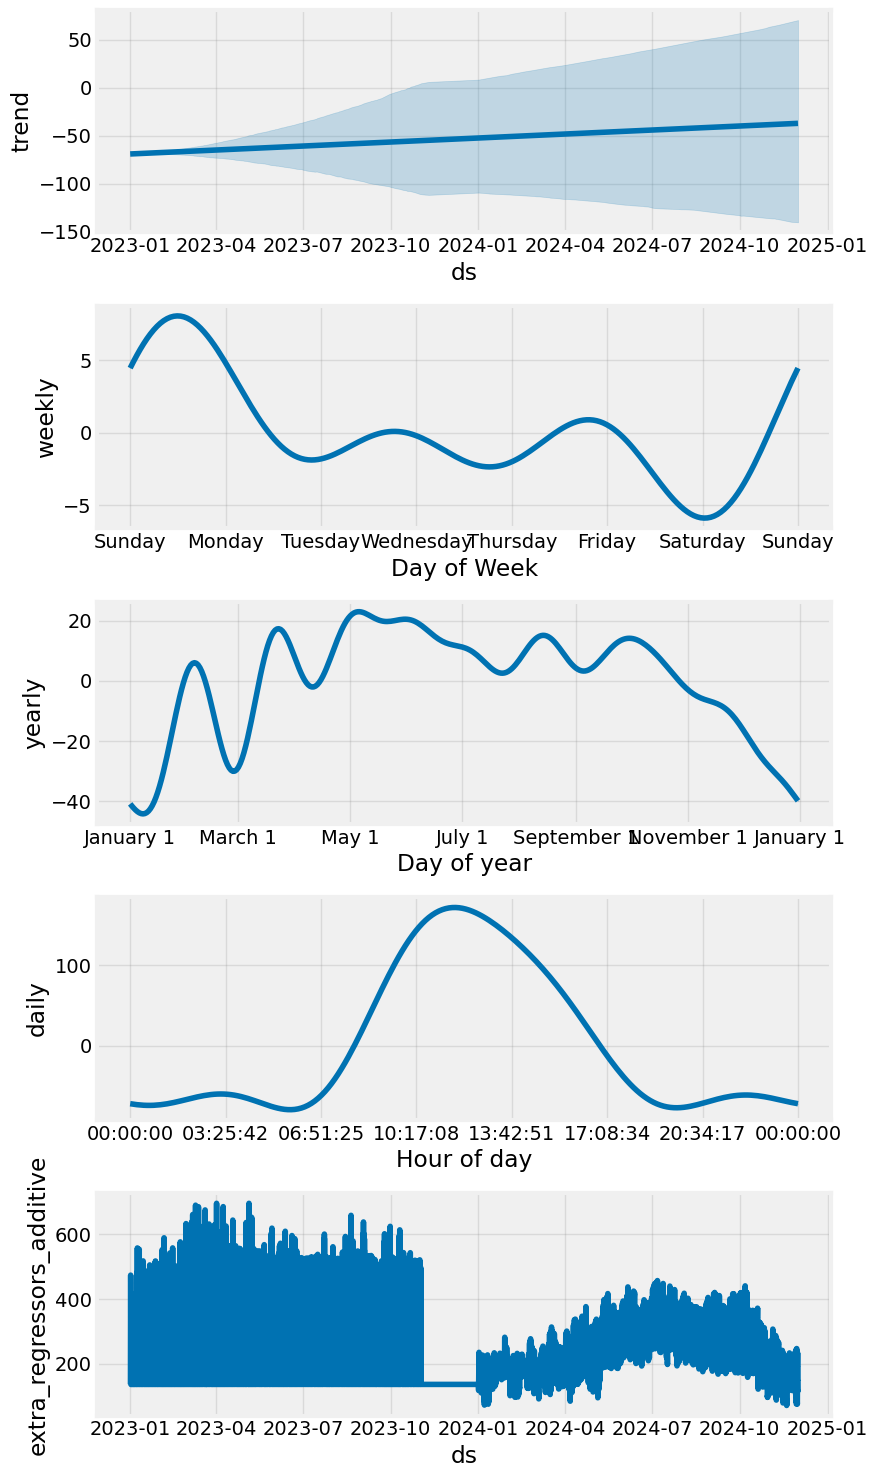

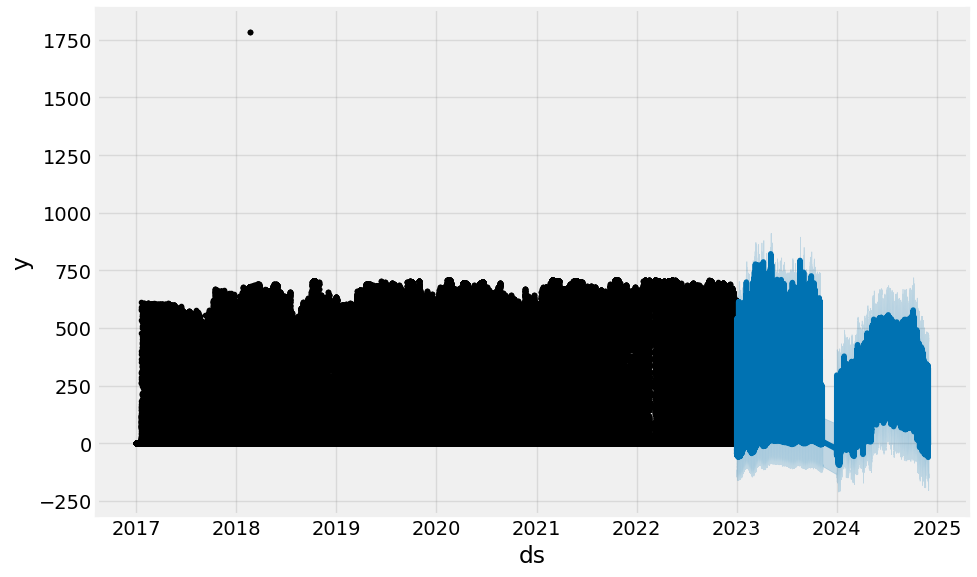

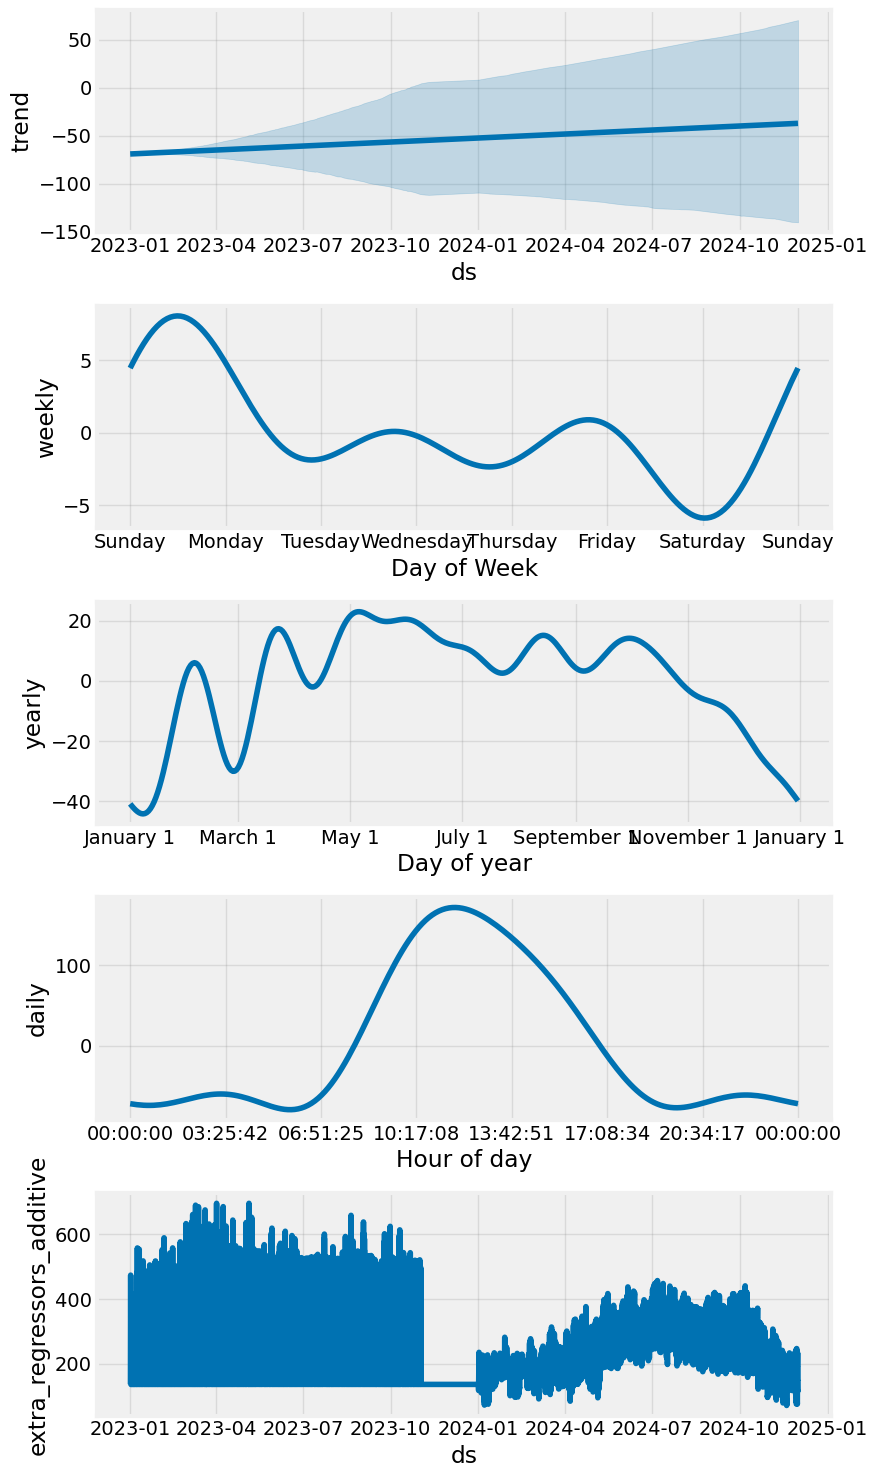

In [14]:
# Built-in Prophet plots
model.plot(forecast)
model.plot_components(forecast)   # shows trend, seasonality, regressor effects

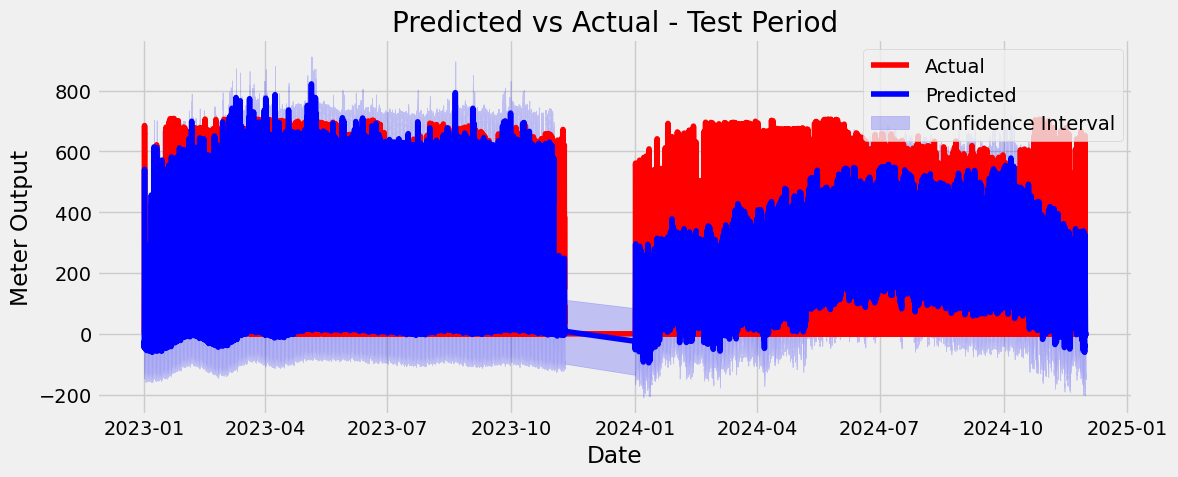

In [15]:
plt.figure(figsize=(12, 5))

# Actual values from test set
plt.plot(df_test['ds'], df_test['y'], color='red', label='Actual')

# Predicted values — filter forecast to test period only
forecast_test = forecast[forecast['ds'].isin(df_test['ds'])]
plt.plot(forecast_test['ds'], forecast_test['yhat'], color='blue', label='Predicted')

# Confidence interval
plt.fill_between(forecast_test['ds'],
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 alpha=0.2, color='blue', label='Confidence Interval')

plt.title('Predicted vs Actual - Test Period')
plt.xlabel('Date')
plt.ylabel('Meter Output')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
mean_squared_error(y_true=df_test['y'],
                   y_pred=forecast['yhat'])

8328.746104387086

In [17]:
mean_absolute_error(y_true=df_test['y'],
                   y_pred=forecast['yhat'])

62.74249717843706

Error Metrics

Our MSE error is 8328.746104387086




Our MAE error is 62.74249717843706


